# Testing

In [2]:
import sys

sys.path.append("D:/Masters/Deep Learning/Project/retina_unet_clean")

import matplotlib.patches as patches

In [2]:
from test_training import test_training_pipeline

In [3]:
test_training_pipeline()

Testing Retina U-Net Training Pipeline
Using GPU: NVIDIA GeForce RTX 3060 Laptop GPU

[1/4] Generating dummy dataset...
Generating 2 training samples...
  Created DUMMY_0000: 1 object(s)
  Created DUMMY_0001: 1 object(s)
Generating 1 validation samples...
  Created DUMMY_VAL_0000: 1 object(s)

Dataset created at: ./dummy_data_test
  Total samples: 3
  Train: 2, Val: 1
  Metadata saved: dummy_data_test\metadata.csv
✓ Dummy dataset generated

[2/4] Testing data loading...
  Training batches: 1
  Validation batches: 1
  Batch image shape: torch.Size([2, 1, 320, 320])
  Batch mask shape: torch.Size([2, 1, 320, 320])
✓ Data loading works

[3/4] Testing model forward pass...
Using 2D Retina U-Net with FPN backbone
  Input shape: torch.Size([2, 1, 320, 320])
  Class logits shape: torch.Size([2, 76500, 2])
  BBox deltas shape: torch.Size([2, 76500, 4])
  Segmentation shape: torch.Size([2, 2, 320, 320])
✓ Model forward pass works

[4/4] Testing training loop (1 epoch)...
Using GPU: NVIDIA GeFor

2026-04-08 20:45:25,794 - training - INFO - Training on device: cuda
2026-04-08 20:45:25,796 - training - INFO - Model parameters: 30,994,991
2026-04-08 20:45:25,796 - training - INFO - Starting training...
2026-04-08 20:45:25,797 - training - INFO - 
--- Epoch 1/1 ---
Training:   0%|                                                                                  | 0/1 [00:07<?, ?it/s]

✗ Training loop failed: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.




Traceback (most recent call last):
  File "D:\Masters/Deep Learning/Project/retina_unet_clean\test_training.py", line 118, in test_training_pipeline
    model_trained, trainer = train_model(
                             ^^^^^^^^^^^^
  File "D:\Masters\Deep Learning\Project\retina_unet_clean\train.py", line 743, in train_model
    trainer.train(num_epochs=num_epochs, save_interval=1)
  File "D:\Masters\Deep Learning\Project\retina_unet_clean\train.py", line 641, in train
    train_metrics = self.train_epoch()
                    ^^^^^^^^^^^^^^^^^^
  File "D:\Masters\Deep Learning\Project\retina_unet_clean\train.py", line 490, in train_epoch
    class_loss = compute_focal_loss(
                 ^^^^^^^^^^^^^^^^^^^
  File "D:\Masters\Deep Learning\Project\retina_unet_clean\train.py", line 292, in compute_focal_loss
    p_t = valid_probs.gather(1, valid_targets.unsqueeze(1)).squeeze(1)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
torch.AcceleratorError: CUDA error: device-s

False

In [26]:
from generate_dummy_data import generate_dummy_dataset
from train import train_model, get_device
import torch
import numpy as np

print("=" * 80)
print("Testing Retina U-Net Training Pipeline")
print("=" * 80)

# Setup
device = get_device()
# device = "cpu"
dummy_data_dir = './dummy_data_test'
checkpoint_dir = './checkpoints_test'
log_dir = './logs_test'

# Step 1: Generate dummy dataset
print("\n[1/4] Generating dummy dataset...")
generate_dummy_dataset(
    output_dir=dummy_data_dir,
    num_train_samples=2,
    num_val_samples=1,
    img_size=(320, 320),
    objects_per_image=1
)
print("✓ Dummy dataset generated")

# Step 2: Test data loading
print("\n[2/4] Testing data loading...")
try:
    from data_loader import LIDCDataLoader
    
    dataloaders = LIDCDataLoader.create_dataloaders(
        dummy_data_dir,
        batch_size=2,
        num_workers=0,
        target_size=(320, 320)
    )
    
    train_loader = dataloaders['train']
    val_loader = dataloaders['val']
    
    print(f"  Training batches: {len(train_loader)}")
    print(f"  Validation batches: {len(val_loader)}")
    
    # Check first batch
    batch = next(iter(train_loader))
    print(f"  Batch image shape: {batch['image'].shape}")
    print(f"  Batch mask shape: {batch['mask'].shape}")
    print("✓ Data loading works")
    
except Exception as e:
    print(f"✗ Data loading failed: {e}")
    import traceback
    traceback.print_exc()

# Step 3: Test model forward pass
print("\n[3/4] Testing model forward pass...")
try:
    from model import RetinaUNet
    from train import transform_batch_to_retina_format
    
    model = RetinaUNet(
        in_channels=1,
        num_classes=2,
        dim=2,
        fpn_base_channels=32,  # Smaller for testing
        fpn_out_channels=96,
        rpn_hidden_channels=128
    )
    model.to(device)
    model.eval()
    
    with torch.no_grad():
        batch_data = transform_batch_to_retina_format(batch, device, dim=2)
        images = batch_data['images']
        
        print(f"  Input shape: {images.shape}")
        
        outputs = model(images)
        
        print(f"  Class logits shape: {outputs['class_logits'].shape}")
        print(f"  BBox deltas shape: {outputs['bbox_deltas'].shape}")
        print(f"  Segmentation shape: {outputs['segmentation'].shape}")
        print("✓ Model forward pass works")
        
except Exception as e:
    print(f"✗ Model forward pass failed: {e}")
    import traceback
    traceback.print_exc()

# Step 4: Test training loop
print("\n[4/4] Testing training loop (1 epoch)...")
try:
    # Train for 1 epoch
    model_trained, trainer = train_model(
        data_dir=dummy_data_dir,
        checkpoint_dir=checkpoint_dir,
        log_dir=log_dir,
        num_epochs=1,
        batch_size=2,
        lr=1e-4,
        num_workers=0,
        dim=2,
        target_size=(320, 320)
    )
    
    print("✓ Training loop completed successfully")
    
except Exception as e:
    print(f"✗ Training loop failed: {e}")
    import traceback
    traceback.print_exc()

Testing Retina U-Net Training Pipeline
Using GPU: NVIDIA GeForce RTX 3060 Laptop GPU

[1/4] Generating dummy dataset...
Generating 2 training samples...
  Created DUMMY_0000: 1 object(s)
  Created DUMMY_0001: 1 object(s)
Generating 1 validation samples...
  Created DUMMY_VAL_0000: 1 object(s)

Dataset created at: ./dummy_data_test
  Total samples: 3
  Train: 2, Val: 1
  Metadata saved: dummy_data_test\metadata.csv
✓ Dummy dataset generated

[2/4] Testing data loading...
  Training batches: 1
  Validation batches: 1
  Batch image shape: torch.Size([2, 1, 320, 320])
  Batch mask shape: torch.Size([2, 1, 320, 320])
✓ Data loading works

[3/4] Testing model forward pass...
Using 2D Retina U-Net with FPN backbone
  Input shape: torch.Size([2, 1, 320, 320])
  Class logits shape: torch.Size([2, 76500, 2])
  BBox deltas shape: torch.Size([2, 76500, 4])
  Segmentation shape: torch.Size([2, 2, 320, 320])
✓ Model forward pass works

[4/4] Testing training loop (1 epoch)...
Using GPU: NVIDIA GeFor

2026-04-09 22:41:09,886 - training - INFO - Training on device: cuda
2026-04-09 22:41:09,886 - training - INFO - Training on device: cuda
2026-04-09 22:41:09,886 - training - INFO - Training on device: cuda
2026-04-09 22:41:09,888 - training - INFO - Model parameters: 31,015,736
2026-04-09 22:41:09,888 - training - INFO - Model parameters: 31,015,736
2026-04-09 22:41:09,888 - training - INFO - Model parameters: 31,015,736
2026-04-09 22:41:09,890 - training - INFO - Starting training...
2026-04-09 22:41:09,890 - training - INFO - Starting training...
2026-04-09 22:41:09,890 - training - INFO - Starting training...
2026-04-09 22:41:09,892 - training - INFO - 
--- Epoch 1/1 ---
2026-04-09 22:41:09,892 - training - INFO - 
--- Epoch 1/1 ---
2026-04-09 22:41:09,892 - training - INFO - 
--- Epoch 1/1 ---
Training: 100%|█| 1/1 [00:02<00:00,  2.47s/it, total_loss=1.0558, class_loss=0.7004, bbox_loss=0.0082, seg_loss=0.6944]
2026-04-09 22:41:12,367 - training - INFO - Train - total_loss: 1.0558

✓ Training loop completed successfully


In [3]:
torch.device('cpu')

device(type='cpu')

In [6]:
from generate_dummy_data import generate_dummy_dataset
from train import train_model, get_device
import matplotlib.pyplot as plt
from data_loader import LIDCDataLoader
import torch
import numpy as np

# generate_dummy_dataset(
#     output_dir='./dummy_data_test',
#     num_train_samples=400,
#     num_val_samples=100,
#     img_size=(320, 320),
#     objects_per_image=1
# )

dataloaders = LIDCDataLoader.create_dataloaders(
    './dummy_data_test',
    batch_size=20,
    num_workers=0,
    target_size=(320, 320)
)

In [4]:
dummy_data_dir = './dummy_data_test'
checkpoint_dir = './checkpoints_test'
log_dir = './logs_test'

generate_dummy_dataset(
    output_dir='./dummy_data_test',
    num_train_samples=500,
    num_val_samples=100,
    img_size=(320, 320),
    objects_per_image=1
)

model_trained, trainer = train_model(
    data_dir=dummy_data_dir,
    checkpoint_dir=checkpoint_dir,
    log_dir=log_dir,
    num_epochs=15,
    batch_size=20,
    lr=1e-3,
    num_workers=0,
    dim=2,
    target_size=(320, 320)
)

Generating 500 training samples...
  Created DUMMY_0000: 1 object(s)
  Created DUMMY_0001: 1 object(s)
  Created DUMMY_0002: 1 object(s)
  Created DUMMY_0003: 1 object(s)
  Created DUMMY_0004: 1 object(s)
  Created DUMMY_0005: 1 object(s)
  Created DUMMY_0006: 1 object(s)
  Created DUMMY_0007: 1 object(s)
  Created DUMMY_0008: 1 object(s)
  Created DUMMY_0009: 1 object(s)
  Created DUMMY_0010: 1 object(s)
  Created DUMMY_0011: 1 object(s)
  Created DUMMY_0012: 1 object(s)
  Created DUMMY_0013: 1 object(s)
  Created DUMMY_0014: 1 object(s)
  Created DUMMY_0015: 1 object(s)
  Created DUMMY_0016: 1 object(s)
  Created DUMMY_0017: 1 object(s)
  Created DUMMY_0018: 1 object(s)
  Created DUMMY_0019: 1 object(s)
  Created DUMMY_0020: 1 object(s)
  Created DUMMY_0021: 1 object(s)
  Created DUMMY_0022: 1 object(s)
  Created DUMMY_0023: 1 object(s)
  Created DUMMY_0024: 1 object(s)
  Created DUMMY_0025: 1 object(s)
  Created DUMMY_0026: 1 object(s)
  Created DUMMY_0027: 1 object(s)
  Created DUM

2026-04-09 23:55:07,639 - training - INFO - Training on device: cuda
2026-04-09 23:55:07,642 - training - INFO - Model parameters: 31,015,736
2026-04-09 23:55:07,643 - training - INFO - Starting training...
2026-04-09 23:55:07,643 - training - INFO - 
--- Epoch 1/15 ---
Training: 100%|█| 25/25 [33:04<00:00, 79.36s/it, total_loss=0.8655, class_loss=0.7792, bbox_loss=0.0028, seg_loss=0.167
2026-04-10 00:28:11,754 - training - INFO - Train - total_loss: 0.8655, class_loss: 0.7792, bbox_loss: 0.0028, seg_loss: 0.1671
Validation: 100%|█| 5/5 [02:15<00:00, 27.19s/it, total_loss=0.7042, class_loss=0.6953, bbox_loss=0.0017, seg_loss=0.014
2026-04-10 00:30:27,694 - training - INFO - Val   - total_loss: 0.7042, class_loss: 0.6953, bbox_loss: 0.0017, seg_loss: 0.0145
2026-04-10 00:30:29,095 - training - INFO - Saved best checkpoint with val_loss: 0.7042
2026-04-10 00:30:29,096 - training - INFO - 
--- Epoch 2/15 ---
Training: 100%|█| 25/25 [28:18<00:00, 67.95s/it, total_loss=0.7046, class_loss=0.

In [34]:
dataloaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x158964f0c10>,
 'val': <torch.utils.data.dataloader.DataLoader at 0x15937691810>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x159375ef010>}

In [7]:
test = next(iter(dataloaders["val"]))

In [8]:
test.keys()

dict_keys(['image', 'mask', 'patient_id', 'slice_idx'])

In [9]:
outputs = model_trained(test["image"].to('cuda'))

In [10]:
img = test["image"]#[0]

In [13]:
mask = test["mask"][0]

In [14]:
test["patient_id"]

['DUMMY_0088',
 'DUMMY_0401',
 'DUMMY_0525',
 'DUMMY_0361',
 'DUMMY_0462',
 'DUMMY_0315',
 'DUMMY_0312',
 'DUMMY_0060',
 'DUMMY_0139',
 'DUMMY_0049',
 'DUMMY_0464',
 'DUMMY_0528',
 'DUMMY_0306',
 'DUMMY_0533',
 'DUMMY_0461',
 'DUMMY_0251',
 'DUMMY_0159',
 'DUMMY_0130',
 'DUMMY_0158',
 'DUMMY_0518']

In [15]:
img.shape

torch.Size([1, 120, 120])

In [16]:
mask.shape

torch.Size([1, 120, 120])

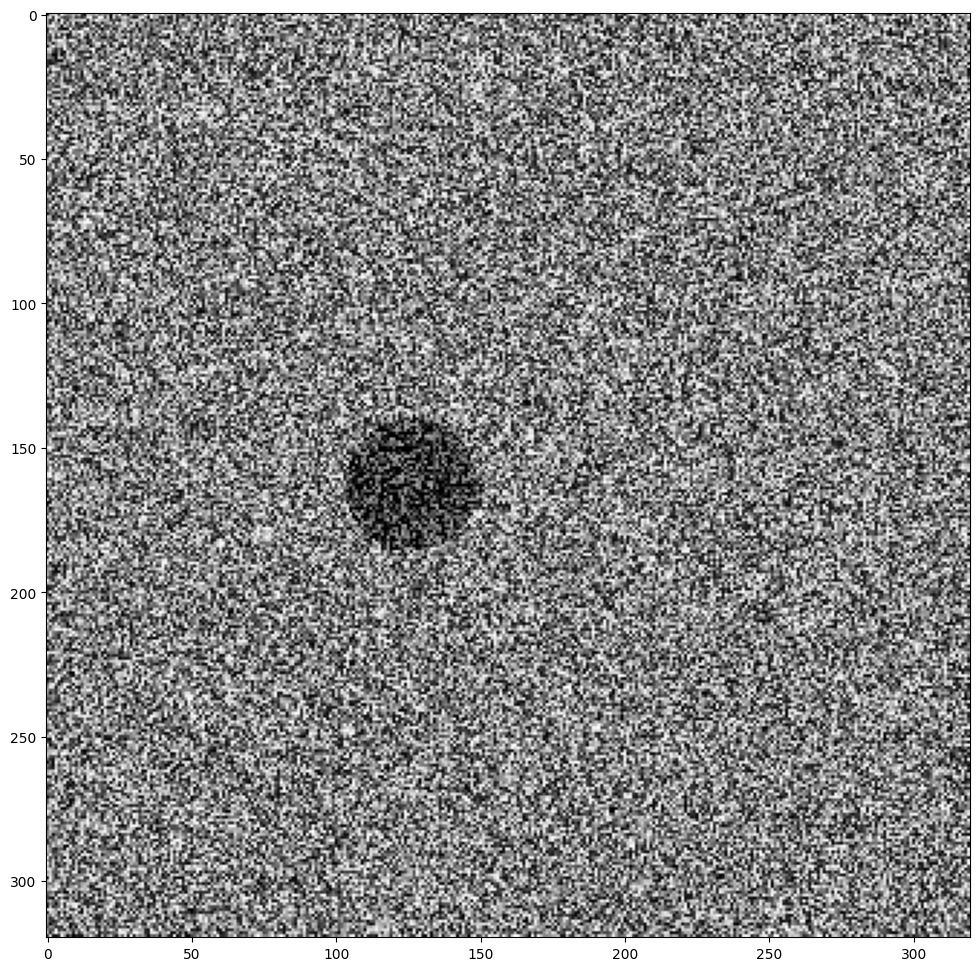

In [12]:
plt.figure(figsize=(12, 12)) 

plt.imshow(img[0][0], cmap='gray_r') #viridis
# plt.imshow(mask[0], cmap='BuGn_r', alpha=0.3) # Overlay mask with 50% opacity

In [39]:
outputs["detections"]#.detach().cpu().numpy()

tensor([[  0.0000,   0.0000,  11.3077,  ...,   0.0000,   1.0000,   0.5052],
        [216.7225, 251.9633, 320.0000,  ...,   0.0000,   1.0000,   0.5047],
        [192.9645,   8.3877, 207.1687,  ...,   0.0000,   1.0000,   0.5040],
        ...,
        [288.9638,   8.3879, 303.1687,  ...,  19.0000,   1.0000,   0.5040],
        [ 84.9644,   8.3877,  99.1686,  ...,  19.0000,   1.0000,   0.5040],
        [265.1380, 115.4792, 310.5265,  ...,  19.0000,   1.0000,   0.5040]],
       device='cuda:0', grad_fn=<CatBackward0>)

In [18]:
import matplotlib.patches as patches

def visualize_retina_outputs(images, detections, threshold=0.5):
    """
    images: (Batch, Channel, Height, Width) - The input tensor
    detections: (N, 7) - The output tensor [y1, x1, y2, x2, batch_id, class_id, score]
    """
    
    # 1. Convert images to Numpy for plotting
    # Permute to (Batch, Height, Width, Channel) for Matplotlib
    images_np = images.permute(0, 2, 3, 1).cpu().numpy()
    
    # If image is grayscale (1 channel), squeeze it to 2D
    if images_np.shape[-1] == 1:
        images_np = images_np.squeeze(-1)
    
    batch_size = images.shape[0]
    
    # Create a figure with subplots for each image in the batch
    fig, axes = plt.subplots(1, batch_size, figsize=(12, 6))
    if batch_size == 1: axes = [axes] # Handle single image case

    for b in range(batch_size):
        ax = axes[b]
        
        # Show the Image
        ax.imshow(images_np[b], cmap='gray')
        ax.set_title(f"Batch Image #{b}")
        ax.axis('off')
        
        # 2. Filter Detections for this Batch ID (Column 4)
        # We only want rows where batch_id == b
        mask = detections[:, 4] == b
        batch_dets = detections[mask]
        
        for row in batch_dets:
            y1, x1, y2, x2, batch_id, class_id, score = row.tolist()
            
            # 3. Score Threshold Filter
            if score < threshold:
                continue
            
            # 4. Coordinate Transformation (Matrix -> Cartesian)
            # Model output: y1 (row), x1 (col)
            # Matplotlib Rect: (x, y), width, height
            width = x2 - x1
            height = y2 - y1
            
            # Create a Rectangle patch
            # Edgecolor 'r' (Red) for visibility, fill=False to see inside
            rect = patches.Rectangle(
                (x1, y1), width, height, 
                linewidth=2, edgecolor='red', facecolor='none'
            )
            
            # Add patch to the plot
            ax.add_patch(rect)
            
            # Add Label (Class + Score)
            label_text = f"Cls {int(class_id)}: {score:.2f}"
            ax.text(
                x1, y1 - 5, label_text, 
                color='white', fontsize=8, backgroundcolor='red'
            )

    plt.tight_layout()
    plt.show()

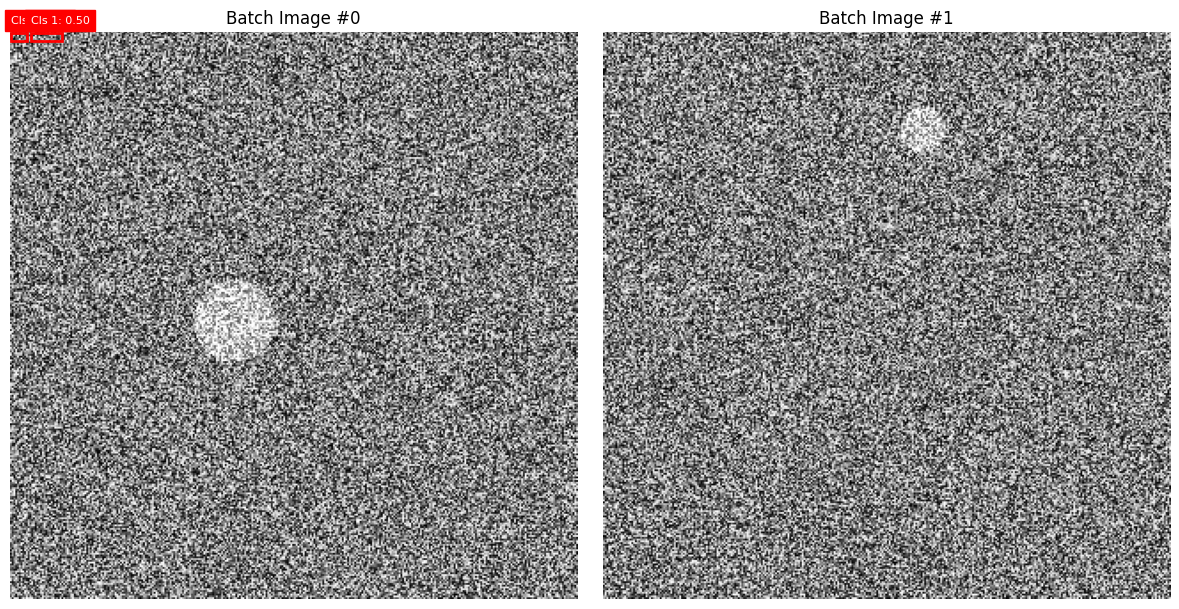

In [19]:
visualize_retina_outputs(img[:2], outputs["detections"][:2], threshold=0.1)